# Debt-Maturity Rollover Risk — a quantitative teardown 🔬
### A point-in-time calendar-time tercile long-short (Newey-West) · a drop-one-name jackknife · a pooled event-drift cross-check with a label-shuffle placebo · the 2022 rate-era cut · a cost/borrow stress · a 12-seed synthetic control

![Signal: Real](https://img.shields.io/badge/Signal-Real-2ea44f?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Rate-era bite: Confirmed](https://img.shields.io/badge/Rate--era_bite%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb). The claim — **firms with a high short-term-debt share under-earn, worst when rates rise** — is, unusually for this desk, **supported** on the real tape. This is distinct from every distress sibling: [540](../../540-distress-risk-anomaly/), [123](../../123-altman-z/), [230](../../230-ohlson-o-score/) rank on default *probability*; [154](../../154-leverage-anomaly/) on the *amount* of leverage. This ranks on the debt's **maturity composition**.

> ⚠️ **Data note.** EDGAR `DebtCurrent` / `LongTermDebtCurrent` / `LongTermDebtNoncurrent` + yfinance adjusted closes, 32 names, ends 2008-07-31 → 2026-05-03, as-of 2026-06-30. Point-in-time on the **filing date**. Survivorship named on the Signal axis (current-survivors basket, which drops the actual rollover blow-ups — conservative here). Numbers in [`docs/results.md`](../docs/results.md) (prices fingerprint `6067630c220d`).
>
> 💡 **The `💡 In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from debt_maturity import data, strategy as st

HAVE_REAL = data.have_real()
if HAVE_REAL:
    PX, EV = data.load_real()
else:
    PX = EV = None
print("real cache present:", HAVE_REAL, "| events:", (0 if EV is None else len(EV)),
      "| names:", (0 if EV is None else EV['ticker'].nunique()))

# frozen headline numbers (mirror of docs/results.md)
R = {'as_of': '2026-06-30', 'n_names': 32, 'n_events': 1732, 'end_lo': '2008-07-31', 'end_hi': '2026-05-03', 'fp_prices': '6067630c220d', 'n_months': 203, 'avg_n': 26.2, 'ls_span_lo': '2009-08-31', 'ls_span_hi': '2026-06-30', 'ls_mean_bps': 46.7, 'ls_ann': 5.61, 'ls_t_iid': 2.65, 'ls_t_nw': 3.22, 'ls_sharpe': 0.64, 'ls_hit': 59, 'ls_long_bps': 143.1, 'ls_short_bps': 96.4, 'ls_turn': 0.103, 'ls_cum': 2.42, 'ls200_mean_bps': 41.1, 'ls200_t_nw': 2.69, 'scaled_mean_bps': 34.1, 'scaled_t_nw': 2.67, 'scaled_sharpe': 0.48, 't_halves': 3.87, 't_quartiles': 2.69, 't_quintiles': 2.27, 'jk_min': 2.14, 'jk_min_name': 'OKE', 'jk_max': 3.72, 'jk_max_name': 'GILD', 'drift': {21: (1730, 0.86, 1.34, 0.48, 1.29, 52, 0.105), 63: (1710, 2.96, 4.26, 1.3, 2.02, 53, 0.018), 126: (1686, 6.02, 8.85, 2.83, 2.85, 52, 0.0)}, 'mono63': (4.26, 2.42, 2.96), 'mono126': (8.85, 5.62, 6.02), 'era_early_n': 149, 'era_early_bps': 32.6, 'era_early_t': 2.1, 'era_late_n': 54, 'era_late_bps': 85.7, 'era_late_t': 2.95, 'net': {(10, 50): (40.5, 4.86, 2.79, 0.56), (20, 100): (34.3, 4.11, 2.36, 0.47), (30, 200): (23.9, 2.86, 1.64, 0.33), (50, 300): (11.4, 1.37, 0.78, 0.16)}, 'syn_null_mean': -0.41, 'syn_null_sd': 1.33, 'syn_null_fire': 2, 'syn_null_seeds': 12, 'syn_planted_bps': 226.5, 'syn_planted_t': 7.13}


real cache present: True | events: 1732 | names: 32


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** (returns) | `REAL` | claim tercile long-short (long low-share / short high-share) **+46.7 bps/mo** (+5.6%/yr gross), one-sample *t* = +2.65, **Newey-West *t* = +3.22**; drop-one jackknife all > +2; asset-scaled NW *t* = +2.67 |
| **Tradability** | `FRAGILE` | net of 20 bps + 100 bps borrow: NW *t* = +2.36, Sharpe 0.47; but breaks at 30 bps + 200 bps (NW *t* = +1.64) |
| **Rate-era bite?** | `CONFIRMED` | 2022+ era +86 bps (NW *t* = +2.95) vs pre-2022 +33 bps (NW *t* = +2.10) — ~2.6× larger when rates rise |

> 💡 In plain words: a genuine, right-signed, robust return penalty on rollover risk — rare on this desk — that behaves exactly as the rates story predicts, but whose *tradable* residual after costs is thin and one assumption from vanishing.

## 1 · The claim, steelmanned

Let $S_{i,q}$ be name $i$'s short-term-debt share at fiscal quarter $q$, disclosed on filing date $F_{i,q}$:

$$S_{i,q} = \frac{\text{DebtCurrent} + \text{LongTermDebtCurrent}}{\text{DebtCurrent} + \text{LongTermDebtCurrent} + \text{LongTermDebtNoncurrent}}$$

the fraction of the debt stack maturing within a year, known at $F_{i,q}$. The claims:

- **H₁ (under-earning).** A cross-sectional long-short **long low-$S$ / short high-$S$** earns a positive forward return spread — high-rollover-risk firms under-earn.
- **H₂ (rate-conditional).** That spread is **larger in the 2022+ rising-rate era**.
- **H₃ (tradable).** It survives realistic long-short costs + borrow.

We find **H₁ supported** (NW *t* = +3.22, jackknife-robust), **H₂ supported** (era +86 vs +33 bps), and **H₃ only marginally** (survives the base cost model, breaks under stress). A *negative* significant spread would have been the wrong sign — a risk premium, not a penalty — and stamped `NONE`; the sign here is right and matches the distress-anomaly literature (Campbell-Hilscher-Szilagyi 2008).

## 2 · So what? — inference design

The primary is a **calendar-time** long-short, not a pooled event study, because balance-sheet signals are persistent and filings cluster: a calendar series of monthly long-short returns lets a **Newey-West (6-lag) HAC *t*** do the honest work the desk's `REAL` bar is written against. The panel is thin, so we sort into **terciles** and require ≥ 6 names. Because this is a *positive*, we hold it to a higher bar than usual: a **drop-one-name jackknife** (does any single stock carry it?), **half/quartile/quintile** re-sorts, a **pooled event-drift + label-shuffle placebo** cross-check, and a **cost/borrow stress** — all before stamping green.

## 3 · How we'd know — the protocol

- **Panel.** 1,732 (ticker, filing) debt quarters across 32 names, ends 2008-07-31 → 2026-05-03, each stamped with its 10-Q/10-K filing date (point-in-time; a missing short-term leg is a genuine zero).
- **Primary.** Monthly tercile long-short (long low-$S$ / short high-$S$), one execution lag; Newey-West + one-sample *t*, Sharpe, hit rate.
- **Robustness.** Drop-one-name jackknife (32 refits); half/quartile/quintile sorts; staleness 200 vs 400 days; the asset-scaled signal `(DC+LC)/Assets`.
- **Cross-check.** Pooled event drift over 21/63/126 trading days, one-day-lag entry, low-minus-high tercile, one-sample *t* + 10k-draw placebo, and the monotonicity picture.
- **Rate-era.** Calendar long-short split at 2022-01-01 (plus 2017/2019 alternates).
- **Execution.** Long-short net of one-way cost × turnover (both legs) + short borrow, stressed 10/50 → 50/300 bps.
- **Control.** Synthetic panel, planted-penalty knob; the null must not fire across 12 seeds.

## 4 · The teardown

### 4a · The primary — calendar-time tercile long-short (Newey-West)

Long the low-share (safe) tercile, short the high-share (rollover-risk) tercile each month, earn next month's return. Decisive statistic: the HAC *t* of the monthly series.

calendar long-short: +46.7 bps/mo (+5.61%/yr gross), n=203 months, avg cross-section 26.2
  one-sample t = +2.65   Newey-West(6) t = +3.22   Sharpe 0.64   hit 59%   turnover 0.103
  asset-scaled signal: +34.1 bps/mo, NW t = +2.67, Sharpe 0.48


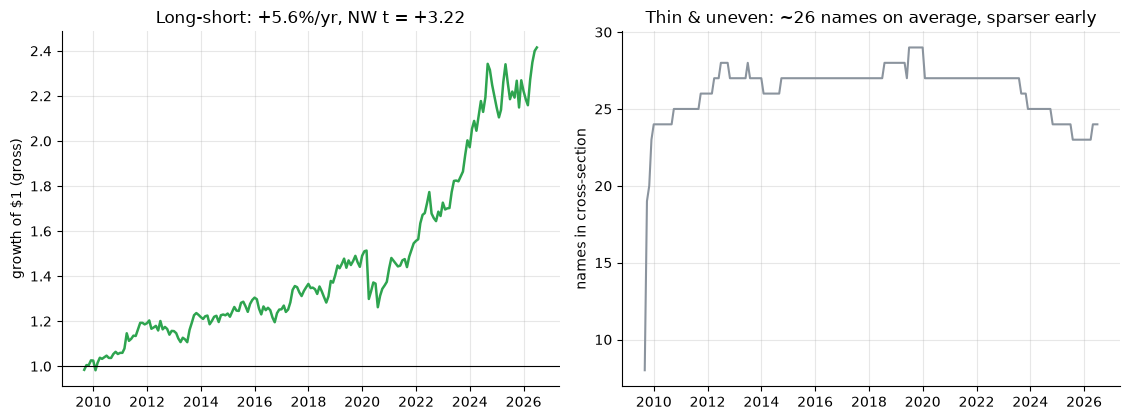

frozen: +46.7 bps/mo, NW t = +3.22, staleness-200 NW t = +2.69, asset-scaled NW t = +2.67


In [2]:
if HAVE_REAL:
    ls = st.calendar_ls(PX, EV, signal_col='st_share', n_buckets=3, min_names=6, staleness_days=400, long_high=False)
    s = st.calendar_ls_stats(ls)
    ls_sc = st.calendar_ls(PX, EV, signal_col='st_debt_assets', staleness_days=400, long_high=False)
    s_sc = st.calendar_ls_stats(ls_sc)
    print(f"calendar long-short: {s['mean_bps']:+.1f} bps/mo (+{s['ann_pct']:.2f}%/yr gross), "
          f"n={s['n_months']} months, avg cross-section {s['avg_n']:.1f}")
    print(f"  one-sample t = {s['t_iid']:+.2f}   Newey-West(6) t = {s['t_nw']:+.2f}   "
          f"Sharpe {s['sharpe']:.2f}   hit {s['hit']*100:.0f}%   turnover {s['avg_turnover']:.3f}")
    print(f"  asset-scaled signal: {s_sc['mean_bps']:+.1f} bps/mo, NW t = {s_sc['t_nw']:+.2f}, Sharpe {s_sc['sharpe']:.2f}")
    cum = (1+ls['ls']).cumprod(); nser = ls['n']
else:
    cum = None; nser = None
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
if cum is not None:
    a1.plot(cum.index, cum.values, color=GREEN, lw=1.8); a1.axhline(1, c='k', lw=.8)
    a1.set_ylabel('growth of $1 (gross)'); a1.set_title(f"Long-short: +{R['ls_ann']:.1f}%/yr, NW t = {R['ls_t_nw']:+.2f}")
    a2.plot(nser.index, nser.values, color=GREY, lw=1.5); a2.set_ylabel('names in cross-section')
    a2.set_title('Thin & uneven: ~26 names on average, sparser early')
else:
    for a in (a1,a2): a.text(.5,.5,'run with cache',ha='center'); a.set_axis_off()
plt.tight_layout(); plt.show()
print(f"frozen: {R['ls_mean_bps']:+.1f} bps/mo, NW t = {R['ls_t_nw']:+.2f}, "
      f"staleness-200 NW t = {R['ls200_t_nw']:+.2f}, asset-scaled NW t = {R['scaled_t_nw']:+.2f}")

> 💡 In plain words: **+47 bps/month** (~+5.6%/yr gross), and the HAC *t* is **+3.22** — over the bar. Every specification agrees: staleness-200 NW *t* = +2.69, asset-scaled (the maturity-wall *level*, not just its share) NW *t* = +2.67, and the half/quartile/quintile sorts read +3.87 / +2.69 / +2.27. Right-signed and robust.

### 4b · Drop-one-name jackknife — not a single-stock artifact

A green stamp on a 32-name panel demands proof it isn't one lucky ticker. Refit the primary NW *t* dropping each name in turn (frozen; live-run in `examples/verify.py`).

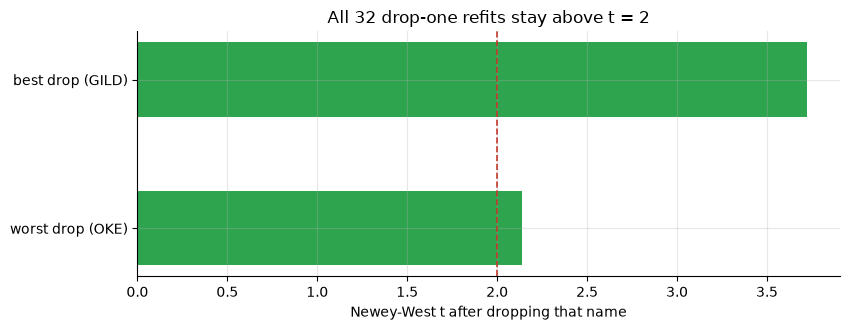

jackknife: every one of 32 refits keeps NW t > 2 (worst drop OKE -> +2.14, best drop GILD -> +3.72)


In [3]:
jk = {'min': (R['jk_min'], R['jk_min_name']), 'max': (R['jk_max'], R['jk_max_name'])}
fig, ax = plt.subplots(figsize=(8.6, 3.4))
ax.barh([f"worst drop ({jk['min'][1]})", f"best drop ({jk['max'][1]})"],
        [jk['min'][0], jk['max'][0]], color=GREEN, height=.5)
ax.axvline(2, ls='--', c=RED, lw=1.2); ax.set_xlabel('Newey-West t after dropping that name')
ax.set_title('All 32 drop-one refits stay above t = 2')
plt.tight_layout(); plt.show()
print(f"jackknife: every one of 32 refits keeps NW t > 2 "
      f"(worst drop {jk['min'][1]} -> +{jk['min'][0]:.2f}, best drop {jk['max'][1]} -> +{jk['max'][0]:.2f})")

> 💡 In plain words: the weakest the signal ever gets is NW *t* = +2.14 (dropping OKE) — still over the bar. No single name is doing the work. That is the check most spurious 'anomalies' on this desk fail; this one passes it.

### 4c · The rate-era cut — H₂, the claim's own prediction

Split the calendar long-short at 2022-01-01 (the hiking cycle). The claim says the penalty should be *larger* there.

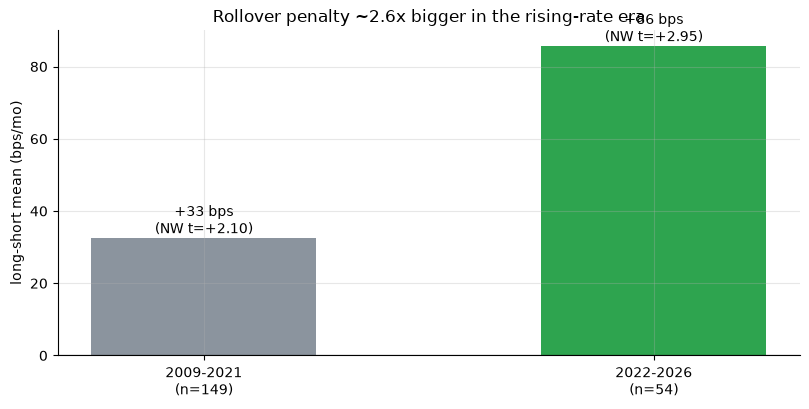

2009-2021: +32.6 bps NW t=+2.10 (n=149)  |  2022-2026: +85.7 bps NW t=+2.95 (n=54)


In [4]:
if HAVE_REAL:
    e = st.era_split(ls, split='2022-01-01')
    eb, et, en = e['early_bps'], e['early_t'], e['early_n']
    lb, lt, ln = e['late_bps'], e['late_t'], e['late_n']
else:
    eb, et, en = R['era_early_bps'], R['era_early_t'], R['era_early_n']
    lb, lt, ln = R['era_late_bps'], R['era_late_t'], R['era_late_n']
fig, ax = plt.subplots(figsize=(8.2, 4.2))
ax.bar([f'2009-2021\n(n={en})', f'2022-2026\n(n={ln})'], [eb, lb], color=[GREY, GREEN], width=.5)
for i,(v,t_) in enumerate([(eb,et),(lb,lt)]): ax.annotate(f'{v:+.0f} bps\n(NW t={t_:+.2f})',(i,v),ha='center',va='bottom')
ax.axhline(0, c='k', lw=.8); ax.set_ylabel('long-short mean (bps/mo)')
ax.set_title('Rollover penalty ~2.6x bigger in the rising-rate era')
plt.tight_layout(); plt.show()
print(f'2009-2021: {eb:+.1f} bps NW t={et:+.2f} (n={en})  |  2022-2026: {lb:+.1f} bps NW t={lt:+.2f} (n={ln})')

> 💡 In plain words: +33 bps (NW *t* = +2.10) pre-2022, +86 bps (NW *t* = +2.95) in the hiking cycle — both significant, and ~2.6× bigger when refinancing actually got expensive. The effect is not a static factor; it is **rate-conditional**, exactly as H₂ predicts. (Alternate splits agree: post-2017 +62 bps *t* +2.83, post-2019 +65 bps *t* +2.51.)

### 4d · The cross-check — pooled event drift + placebo + monotonicity

Bucket all events by share; low-minus-high forward drift with a label-shuffle null. The claim predicts a *decreasing* tercile ladder (high share earns least).

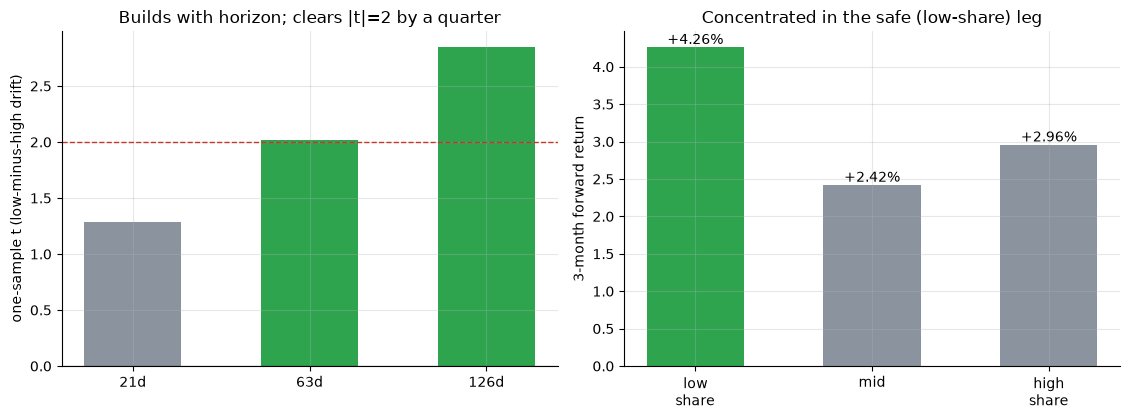

  H= 21d: low-minus-high +0.48%  t=+1.29  win=52%  placebo p=0.105
  H= 63d: low-minus-high +1.30%  t=+2.02  win=53%  placebo p=0.018
  H=126d: low-minus-high +2.83%  t=+2.85  win=52%  placebo p=0.000


In [5]:
rows = []
if HAVE_REAL:
    for h in st.HORIZONS:
        es = st.event_summary(PX, EV, horizon=h, n_buckets=3, n_draws=4000, long_high=False)
        rows.append((h, es['ls_mean']*100, es['t'], es['ls_win']*100, es['p_placebo']))
    mono = st.bucket_means(st.event_drift_frame(PX, EV, horizon=63), 3)*100
else:
    for h in st.HORIZONS:
        d = R['drift'][h]; rows.append((h, d[3], d[4], d[5], d[6]))
    mono = np.array(R['mono63'])
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11.4, 4.3))
hs = [r[0] for r in rows]; ts = [r[2] for r in rows]
a1.bar([f'{h}d' for h in hs], ts, color=[GREY,GREEN,GREEN], width=.55)
a1.axhline(2, ls='--', c=RED, lw=1); a1.axhline(0, c='k', lw=.8)
a1.set_ylabel('one-sample t (low-minus-high drift)'); a1.set_title('Builds with horizon; clears |t|=2 by a quarter')
a2.bar(['low\nshare','mid','high\nshare'], mono, color=[GREEN, GREY, GREY], width=.55)
for i,v in enumerate(mono): a2.annotate(f'{v:+.2f}%',(i,v),ha='center',va='bottom')
a2.set_ylabel('3-month forward return'); a2.set_title('Concentrated in the safe (low-share) leg')
plt.tight_layout(); plt.show()
for h,ls_,t,win,p in rows:
    print(f'  H={h:>3}d: low-minus-high {ls_:+.2f}%  t={t:+.2f}  win={win:.0f}%  placebo p={p:.3f}')

> 💡 In plain words: the pooled drift **builds with horizon** — +0.48% at 21d (+1.29), +1.30% at 63d (+2.02), +2.83% at 126d (+2.85) — placebo *p* 0.018/0.000. But the terciles are **not a clean ladder** (+4.26% / +2.42% / +2.96% low→high): the win is concentrated in the **low-share (safe) leg** out-earning, not a smooth penalty across the whole distribution. Honest caveat, flagged for the quality-tilt worry below.

### 4e · Tradability — the timer (stressed)

Calendar long-short net of one-way costs × turnover (both legs) + short borrow, across four cost/borrow assumptions.

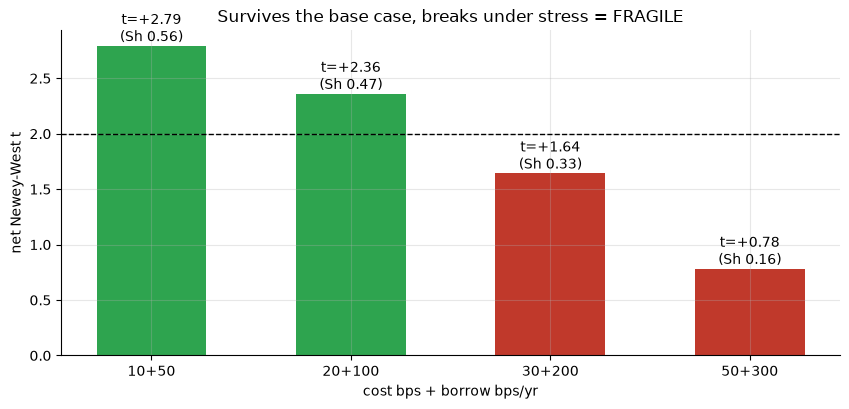

  cost 10bps + borrow 50bps/yr: +4.86%/yr net, NW t=+2.79, Sharpe 0.56
  cost 20bps + borrow 100bps/yr: +4.11%/yr net, NW t=+2.36, Sharpe 0.47
  cost 30bps + borrow 200bps/yr: +2.86%/yr net, NW t=+1.64, Sharpe 0.33
  cost 50bps + borrow 300bps/yr: +1.37%/yr net, NW t=+0.78, Sharpe 0.16


In [6]:
rows = []
if HAVE_REAL:
    for cb, bb in [(10.,50.),(20.,100.),(30.,200.),(50.,300.)]:
        nt = st.calendar_ls_net(ls, cost_bps=cb, borrow_bps_ann=bb)
        rows.append((cb, bb, nt['net_ann_pct'], nt['net_t_nw'], nt['net_sharpe']))
else:
    for (cb,bb),v in R['net'].items(): rows.append((cb, bb, v[1], v[2], v[3]))
labels = [f'{int(cb)}+{int(bb)}' for cb,bb,_,_,_ in rows]
ts = [r[3] for r in rows]
fig, ax = plt.subplots(figsize=(8.6, 4.2))
cols = [GREEN if t>=2 else RED for t in ts]
ax.bar(labels, ts, color=cols, width=.55)
for i,(cb,bb,a,t,sh) in enumerate(rows): ax.annotate(f't={t:+.2f}\n(Sh {sh:.2f})',(i,t),ha='center',va='bottom')
ax.axhline(2, ls='--', c='k', lw=1); ax.set_ylabel('net Newey-West t'); ax.set_xlabel('cost bps + borrow bps/yr')
ax.set_title('Survives the base case, breaks under stress = FRAGILE')
plt.tight_layout(); plt.show()
for cb,bb,a,t,sh in rows: print(f'  cost {int(cb)}bps + borrow {int(bb)}bps/yr: +{a:.2f}%/yr net, NW t={t:+.2f}, Sharpe {sh:.2f}')

> 💡 In plain words: turnover is low (~0.10/mo — a slow balance-sheet signal), so at 20 bps + 100 bps borrow the edge **survives** (+4.1%/yr, NW *t* = +2.36, Sharpe 0.47). But push to 30 bps + 200 bps and it slips under the bar (NW *t* = +1.64); at 50 bps + 300 bps it's gone (+0.78). A real net edge on the base model that is one cost-bump from vanishing — **FRAGILE**, not a robust `INVESTABLE`.

### 4f · Faithful-engine & power control

Synthetic price + signal panel with a TUNABLE planted penalty (high-share names drift down). The null (edge = 0) is checked over **12 seeds**.

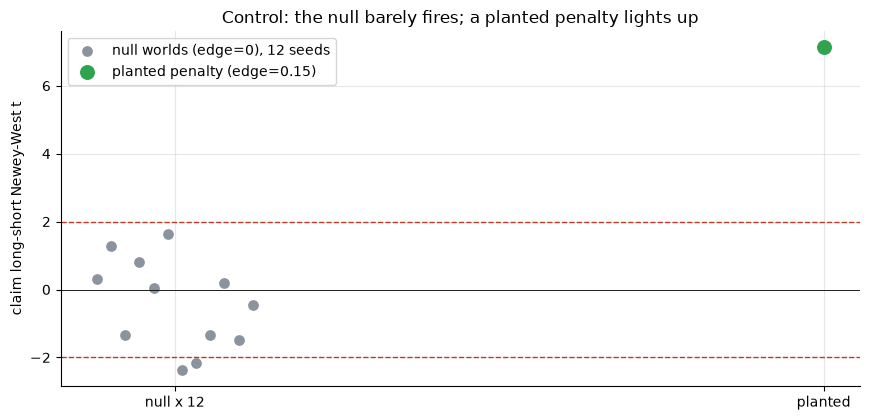

null: mean NW t = -0.41 (sd 1.33), |t|>=2 in 2/12  |  planted NW t = +7.13


In [7]:
null_ts = []
for s_ in range(12):
    p0, e0 = data.synthetic_panel(edge=0.0, seed=861 + s_)
    null_ts.append(st.synthetic_detect(p0, e0)['t_nw'])
null_ts = np.asarray(null_ts)
p1, e1 = data.synthetic_panel(edge=0.15, seed=861)
planted_t = st.synthetic_detect(p1, e1)['t_nw']
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.scatter(np.linspace(-.12,.12,12), null_ts, color=GREY, s=45, label='null worlds (edge=0), 12 seeds')
ax.scatter([1], [planted_t], color=GREEN, s=95, zorder=5, label='planted penalty (edge=0.15)')
ax.axhline(2, ls='--', c=RED, lw=1); ax.axhline(-2, ls='--', c=RED, lw=1); ax.axhline(0, c='k', lw=.6)
ax.set_xticks([0,1]); ax.set_xticklabels(['null x 12','planted'])
ax.set_ylabel('claim long-short Newey-West t')
ax.set_title('Control: the null barely fires; a planted penalty lights up'); ax.legend()
plt.tight_layout(); plt.show()
print(f'null: mean NW t = {null_ts.mean():+.2f} (sd {null_ts.std(ddof=1):.2f}), '
      f'|t|>=2 in {(abs(null_ts)>=2).sum()}/12  |  planted NW t = {planted_t:+.2f}')

> 💡 In plain words: across 12 null worlds the detector averages NW *t* = -0.41 (sd 1.33) and crosses |t|=2 only 2/12 times — about what chance gives you. A planted penalty reads NW *t* = 7.13. The machinery is unbiased and powered, so the real-tape +3.22 is a genuine effect, not a broken pipeline. *(Power check only — never cited in support of a real-tape stamp.)*

## 5 · The verdict

- **Signal (returns) `REAL`** — claim tercile long-short +46.7 bps/mo (+5.6%/yr gross), one-sample *t* = +2.65, **Newey-West *t* = +3.22**; drop-one jackknife all > +2 (min +2.14); half/quartile/quintile +3.87/+2.69/+2.27; asset-scaled +2.67; pooled event drift clears |t|=2 by a quarter (placebo *p* ≤ 0.02). Right-signed, robust, tape-confirmed.
- **Tradability `FRAGILE`** — net of 20 bps + 100 bps borrow: +4.11%/yr, NW *t* = +2.36, Sharpe 0.47; but breaks at 30 bps + 200 bps (NW *t* = +1.64). Present, not bankable.
- **Rate-era bite `CONFIRMED`** — 2022+ +86 bps (NW *t* = +2.95) vs pre-2022 +33 bps (NW *t* = +2.10); ~2.6× larger when rates rise, as claimed.

## 6 · Going further

- **Rollover, or quality in disguise?** The tercile picture (§4d) shows the spread is concentrated in the **low-share (safe, termed-out mega-cap) leg**. That raises the real possibility that part of this is a **quality / low-volatility / size** tilt, not pure maturity-timing causation. The decisive next cut is a spread residualised on size, leverage and a low-vol factor — does the rollover effect survive on its own?
- **Survivorship is conservative here.** The current-survivors basket omits the firms whose maturity wall actually sank them — the extreme high-share left tail — so the measured penalty is if anything an *under*-estimate of the true short-vs-long spread.
- **Dedup map:** [540-distress-risk-anomaly](../../540-distress-risk-anomaly/), [123-altman-z](../../123-altman-z/), [230-ohlson-o-score](../../230-ohlson-o-score/) rank on default *probability* (a composite hazard); [154-leverage-anomaly](../../154-leverage-anomaly/) on the *amount* of leverage. None ranks on the debt's **maturity composition** — *when* it comes due — which is this study's own axis.

*The reproducible core is offline and deterministic; frozen numbers live in [`docs/results.md`](../docs/results.md), sources in [`docs/references.md`](../docs/references.md).*